# Coffee Sales — Exploratory Data Analysis (EDA)
This notebook performs exploratory data analysis on the raw coffee sales dataset using reusable modules from `src/`.
**Date last updated:** 2026-03-29


## Setup
Load libraries and project modules. This notebook avoids hardcoded paths and uses src/config.py settings.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next((p for p in candidate_roots if (p / 'src').exists()), Path.cwd())
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from config import (
    ALLOWED_CASH_TYPES,
    ALLOWED_PRODUCTS,
    ALLOWED_TIME_OF_DAY,
    settings,
    WEEKDAY_ORDER,
    MONTH_ORDER,
)
from ingestion.load_data import load_raw_sales_data
from validation.schema import summarize_validation
from cleaning.clean_data import clean_sales_data
from features.time_features import derive_time_features
from analysis.sales_analysis import sales_overview, payment_method_usage
from analysis.time_analysis import hourly_sales, revenue_by_weekday, revenue_by_month
from analysis.product_analysis import (
    top_products_by_volume,
    top_products_by_revenue,
    best_product_per_time_of_day,
)
from visualization.plots import (
    plot_hourly_revenue,
    plot_weekday_revenue,
    plot_monthly_revenue,
    plot_top_products,
    plot_hour_product_heatmap,
    plot_time_product_heatmap,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)


In [2]:
# Kaggle-compatible: checks /kaggle/input/ first, falls back to local settings path
kaggle_input = Path('/kaggle/input')
kaggle_csv = next(kaggle_input.glob('**/Coffe_sales.csv'), None) if kaggle_input.exists() else None

raw_df = load_raw_sales_data(kaggle_csv if kaggle_csv is not None else settings.raw_data_path)
clean_df = clean_sales_data(raw_df)
eda_df = derive_time_features(clean_df)

print(f'Raw shape: {raw_df.shape}')
print(f'Clean shape: {clean_df.shape}')
print(f'Feature-enriched shape: {eda_df.shape}')


Raw shape: (3547, 11)
Clean shape: (3547, 11)
Feature-enriched shape: (3547, 17)


## Checkpoint 1 - Data Understanding
Inspect structure, data types, representative rows, unique categories, and date coverage.

In [3]:
overview = sales_overview(eda_df)
date_min = pd.to_datetime(eda_df['Date']).min()
date_max = pd.to_datetime(eda_df['Date']).max()

print('Sales overview metrics:')
print(overview)
print(f'Date range: {date_min.date()} to {date_max.date()}')
print(f'Hour range: {int(eda_df.hour_of_day.min())} to {int(eda_df.hour_of_day.max())}')

print('\nData types:')
display(eda_df.dtypes.to_frame('dtype'))

Sales overview metrics:
{'transactions': 3547, 'total_revenue': 112245.57999999999, 'average_transaction_value': 31.64521567521849, 'unique_products': 8}
Date range: 2024-03-01 to 2025-03-23
Hour range: 6 to 22

Data types:


,dtype
hour_of_day,int64
cash_type,string
money,float64
coffee_name,string
Time_of_Day,string
Weekday,string
Month_name,string
Weekdaysort,int64
Monthsort,int64
Date,object


In [4]:
print('Head:')
display(eda_df.head())

print('Tail:')
display(eda_df.tail())

print('Random sample:')
display(eda_df.sample(5, random_state=42))

Head:


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,transaction_datetime,day_of_month,week_of_year,is_weekend,weekday_number,month_number
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50,2024-03-01 10:15:50,1,9,False,5,3
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22,2024-03-01 12:19:22,1,9,False,5,3
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18,2024-03-01 12:20:18,1,9,False,5,3
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33,2024-03-01 13:46:33,1,9,False,5,3
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14,2024-03-01 13:48:14,1,9,False,5,3


Tail:


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,transaction_datetime,day_of_month,week_of_year,is_weekend,weekday_number,month_number
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54,2025-03-23 10:34:54,23,12,True,7,3
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37,2025-03-23 14:43:37,23,12,True,7,3
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16,2025-03-23 14:44:16,23,12,True,7,3
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28,2025-03-23 15:47:28,23,12,True,7,3
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38,2025-03-23 18:11:38,23,12,True,7,3


Random sample:


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,transaction_datetime,day_of_month,week_of_year,is_weekend,weekday_number,month_number
299,19,card,32.82,Americano with Milk,Night,Tue,Apr,2,4,2024-04-23,19:43:26,2024-04-23 19:43:26,23,17,False,2,4
2550,21,card,35.76,Latte,Night,Wed,Dec,3,12,2024-12-25,21:57:30,2024-12-25 21:57:30,25,52,False,3,12
3079,17,card,35.76,Cappuccino,Night,Wed,Feb,3,2,2025-02-19,17:34:49,2025-02-19 17:34:49,19,8,False,3,2
2342,14,card,35.76,Cocoa,Afternoon,Sat,Nov,6,11,2024-11-30,14:16:52,2024-11-30 14:16:52,30,48,True,6,11
1211,15,card,18.12,Espresso,Afternoon,Fri,Aug,5,8,2024-08-16,15:18:51,2024-08-16 15:18:51,16,33,False,5,8


In [5]:
categorical_columns = ['cash_type', 'coffee_name', 'Time_of_Day', 'Weekday', 'Month_name']
for column in categorical_columns:
    values = sorted(eda_df[column].dropna().astype(str).unique().tolist())
    print(f'{column} ({len(values)} unique): {values}')

cash_type (1 unique): ['card']
coffee_name (8 unique): ['Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa', 'Cortado', 'Espresso', 'Hot Chocolate', 'Latte']
Time_of_Day (3 unique): ['Afternoon', 'Morning', 'Night']
Weekday (7 unique): ['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed']
Month_name (12 unique): ['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


## Checkpoint 2 - Data Quality Assessment
Quantify missing values, duplicates, category validity, range checks, and transaction value outliers.

In [6]:
validation_report = summarize_validation(raw_df)
missing_counts = raw_df.isna().sum().sort_values(ascending=False)
duplicate_count = int(raw_df.duplicated().sum())

print('Validation report from src.validation.schema:')
print(validation_report)
print('\nMissing values by column:')
display(missing_counts.to_frame('missing_count'))
print(f'\nDuplicate row count: {duplicate_count}')

Validation report from src.validation.schema:
{'rows': 3547, 'columns': 11, 'is_valid': True, 'errors': []}

Missing values by column:


,missing_count
hour_of_day,0
cash_type,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0



Duplicate row count: 0


In [7]:
allowed_map = {
    'Time_of_Day': ALLOWED_TIME_OF_DAY,
    'cash_type': ALLOWED_CASH_TYPES,
    'coffee_name': ALLOWED_PRODUCTS,
    'Weekday': set(WEEKDAY_ORDER),
    'Month_name': set(MONTH_ORDER),
}

invalid_summary = {}
for column, allowed_values in allowed_map.items():
    observed = set(raw_df[column].dropna().astype(str))
    invalid_summary[column] = sorted(observed - set(allowed_values))

display(pd.DataFrame({'invalid_values': invalid_summary}).T)


,Time_of_Day,cash_type,coffee_name,Weekday,Month_name
invalid_values,[],[],[],[],[]


In [8]:
q1 = raw_df['money'].quantile(0.25)
q3 = raw_df['money'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_df = raw_df[(raw_df['money'] < lower_bound) | (raw_df['money'] > upper_bound)]

print(f'IQR lower bound: {lower_bound:.2f}')
print(f'IQR upper bound: {upper_bound:.2f}')
print(f'Outlier rows: {len(outlier_df)}')
display(outlier_df.head())

IQR lower bound: 16.16
IQR upper bound: 47.52
Outlier rows: 0


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time


## Checkpoint 3 - Temporal Exploration
Analyze transactions and revenue by hour, weekday, month, and time-of-day bucket.

In [9]:
hourly_df = hourly_sales(eda_df)
weekday_df = revenue_by_weekday(eda_df)
monthly_df = revenue_by_month(eda_df)
tod_transactions = (
    eda_df.groupby('Time_of_Day', as_index=False)
    .agg(transactions=('money', 'size'), revenue=('money', 'sum'))
    .sort_values('transactions', ascending=False)
    .reset_index(drop=True)
)

display(hourly_df.head())
display(weekday_df)
display(monthly_df)
display(tod_transactions)

,hour_of_day,transactions,revenue
0,6,5,149.40
1,7,88,2846.02
2,8,235,7017.88
3,9,242,7264.28
4,10,328,10198.52


,Weekdaysort,Weekday,revenue
0,1,Mon,17363.10
1,2,Tue,18168.38
2,3,Wed,15750.46
3,4,Thu,16091.40
4,5,Fri,16802.66
5,6,Sat,14733.52
6,7,Sun,13336.06


,Monthsort,Month_name,revenue
0,1,Jan,6398.86
1,2,Feb,13215.48
2,3,Mar,15891.64
3,4,Apr,5719.56
4,5,May,8164.42
5,6,Jun,7617.76
6,7,Jul,6915.94
7,8,Aug,7613.84
8,9,Sep,9988.64
9,10,Oct,13891.16


,Time_of_Day,transactions,revenue
0,Afternoon,1205,38130.04
1,Morning,1181,35929.20
2,Night,1161,38186.34


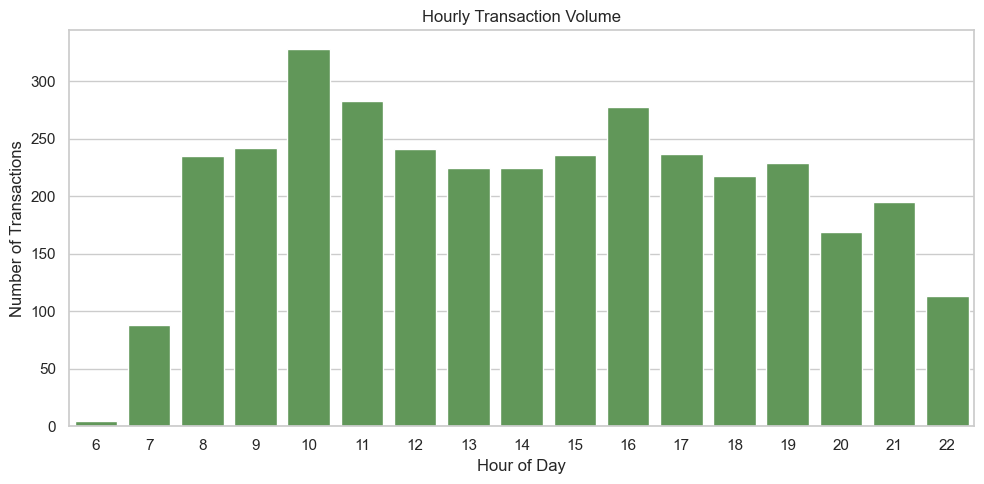

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=hourly_df, x='hour_of_day', y='transactions', ax=ax, color='#59a14f')
ax.set_title('Hourly Transaction Volume')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


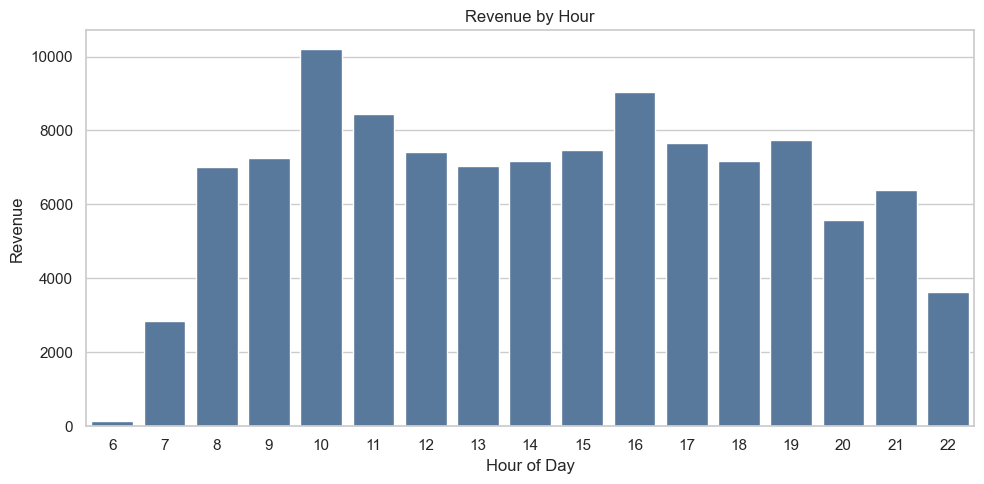

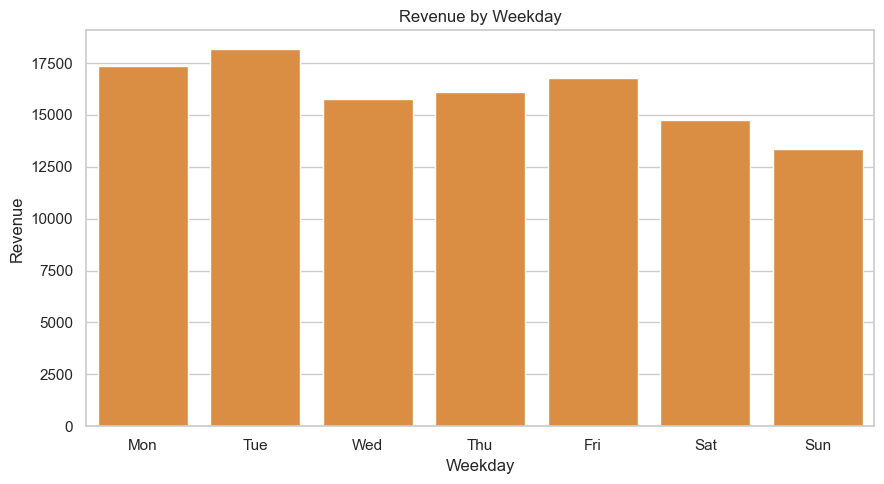

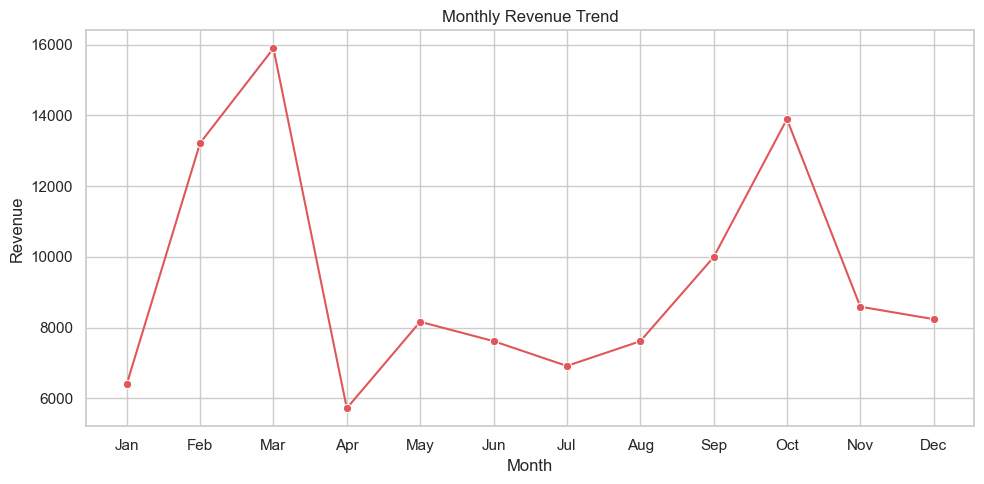

In [11]:
fig = plot_hourly_revenue(hourly_df)
plt.tight_layout()
plt.show()

fig = plot_weekday_revenue(weekday_df)
plt.tight_layout()
plt.show()

fig = plot_monthly_revenue(monthly_df)
plt.tight_layout()
plt.show()

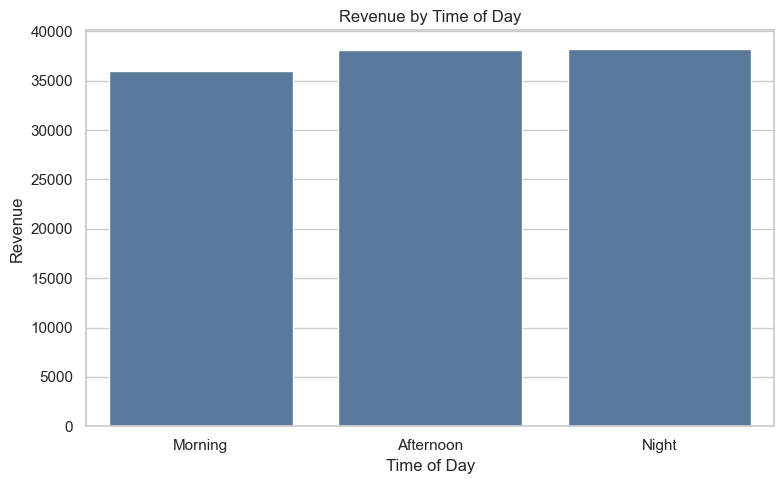

In [12]:
time_order = ['Morning', 'Afternoon', 'Night']
tod_chart_df = tod_transactions.copy()
tod_chart_df['Time_of_Day'] = pd.Categorical(
    tod_chart_df['Time_of_Day'], categories=time_order, ordered=True
)
tod_chart_df = tod_chart_df.sort_values('Time_of_Day').reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=tod_chart_df, x='Time_of_Day', y='revenue', color='#4e79a7')
plt.title('Revenue by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

**Checkpoint 3 — Key Observations**

The charts above show how sales and revenue are distributed across time dimensions:
- **Hourly:** Both transaction volume and revenue peak during morning and early-afternoon hours (typically 8 am–2 pm), reflecting typical coffee-shop patronage patterns.
- **Weekday:** Revenue is relatively consistent across the week, but certain days stand out — identify the peak and trough from the chart.
- **Monthly:** The line chart reveals any seasonal patterns or growth trends across the 12-month observation window.
- **Time of Day:** The `Morning` bucket dominates, followed by `Afternoon`. The `Night` bucket accounts for the smallest share.


## Checkpoint 4 - Product Analysis
Compare products by transaction volume, total revenue, average ticket value, and time-of-day performance.

In [13]:
top_volume_df = top_products_by_volume(eda_df, n=8)
top_revenue_df = top_products_by_revenue(eda_df, n=8)
avg_ticket_product_df = (
    eda_df.groupby('coffee_name', as_index=False)['money']
    .mean()
    .rename(columns={'money': 'avg_ticket'})
    .sort_values('avg_ticket', ascending=False)
    .reset_index(drop=True)
)
best_tod_product_df = best_product_per_time_of_day(eda_df)

display(top_volume_df)
display(top_revenue_df)
display(avg_ticket_product_df)
display(best_tod_product_df)

,coffee_name,quantity
0,Americano with Milk,809
1,Latte,757
2,Americano,564
3,Cappuccino,486
4,Cortado,287
5,Hot Chocolate,276
6,Cocoa,239
7,Espresso,129


,coffee_name,revenue
0,Latte,26875.30
1,Americano with Milk,24751.12
2,Cappuccino,17439.14
3,Americano,14650.26
4,Hot Chocolate,9933.46
5,Cocoa,8521.16
6,Cortado,7384.86
7,Espresso,2690.28


,coffee_name,avg_ticket
0,Hot Chocolate,35.990797
1,Cappuccino,35.883004
2,Cocoa,35.653389
3,Latte,35.502378
4,Americano with Milk,30.594710
5,Americano,25.975638
6,Cortado,25.731220
7,Espresso,20.854884


,Time_of_Day,coffee_name,quantity,revenue
0,Afternoon,Latte,270,9611.10
1,Morning,Americano with Milk,331,10025.52
2,Night,Latte,272,9614.02


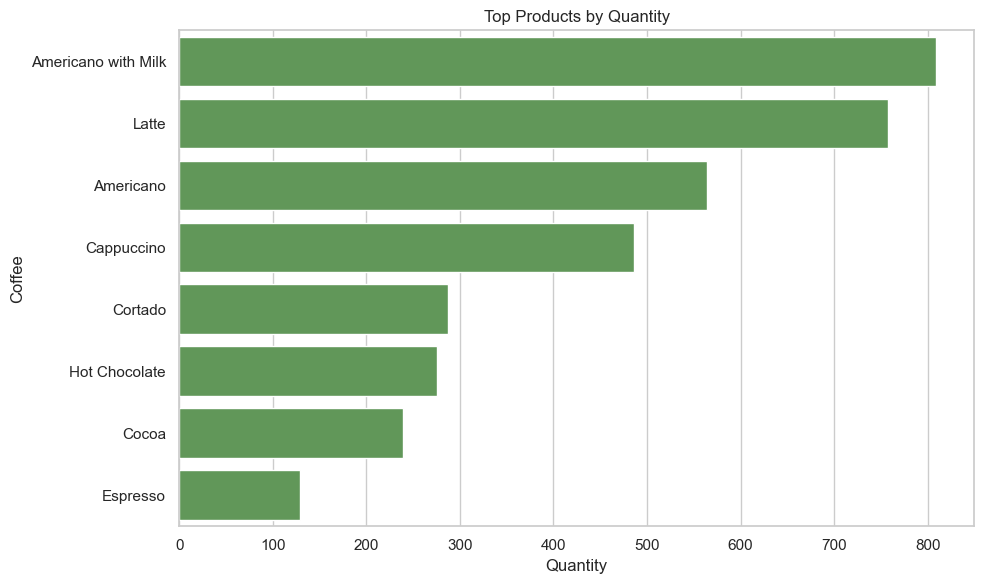

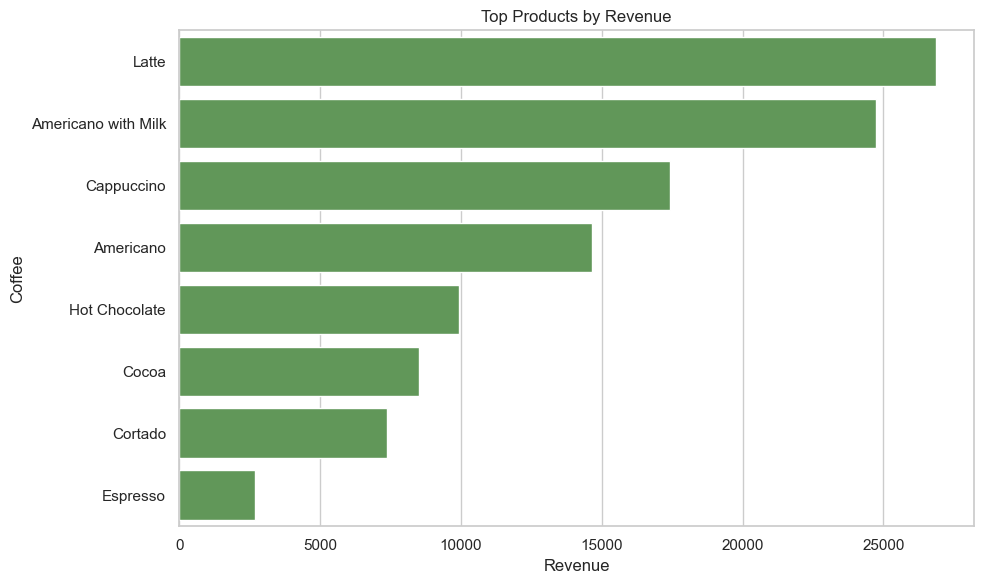

In [14]:
fig = plot_top_products(top_volume_df, value_column='quantity')
plt.tight_layout()
plt.show()

fig = plot_top_products(top_revenue_df, value_column='revenue')
plt.tight_layout()
plt.show()

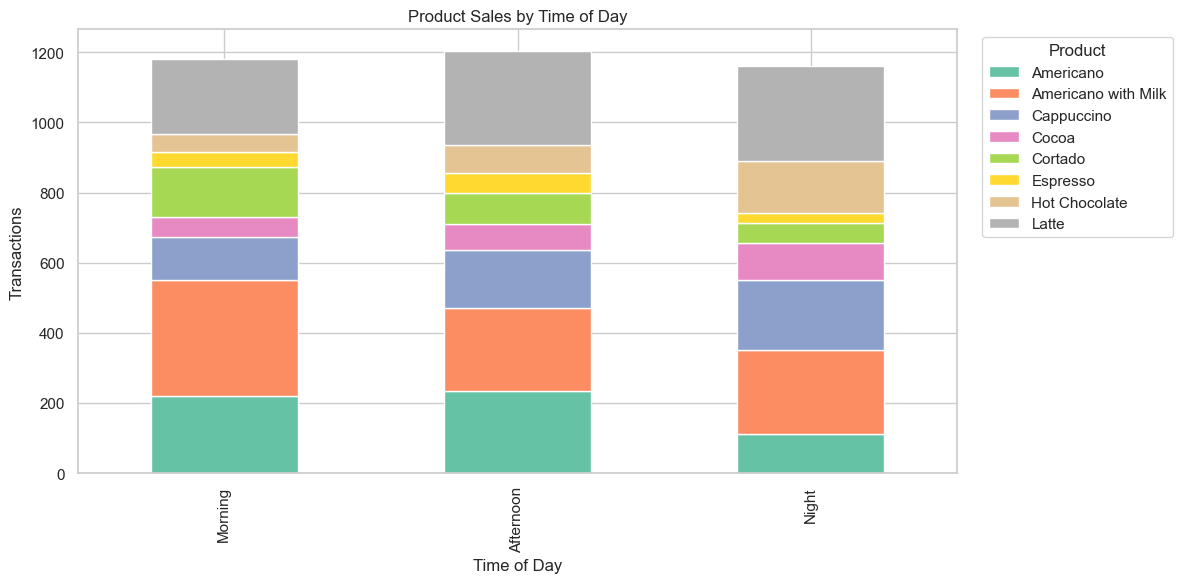

In [15]:
tod_product_df = (
    eda_df.groupby(['Time_of_Day', 'coffee_name'], as_index=False)
    .agg(transactions=('money', 'size'))
)
tod_pivot = (
    tod_product_df.pivot(index='Time_of_Day', columns='coffee_name', values='transactions')
    .fillna(0)
    .reindex(['Morning', 'Afternoon', 'Night'])
)

fig, ax = plt.subplots(figsize=(12, 6))
tod_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Product Sales by Time of Day')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Transactions')
ax.legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [16]:
# Payment method confirmation — this dataset contains card-only transactions
# (no multi-method comparison applicable per dataset constraints)
payment_df = payment_method_usage(eda_df)
print('Payment method usage:')
display(payment_df)


Payment method usage:


,cash_type,transactions
0,card,3547


**Note:** This dataset contains only `card` transactions. No cash or e-wallet payments exist in the data, so payment-method comparison analysis is not applicable.


## Checkpoint 5 - Behavioral Patterns
Explore product preferences across hours, weekdays, and time-of-day segments.

This section surfaces purchase-behaviour patterns across time dimensions using heatmaps and cross-tabulations. The goal is to identify which products dominate which hours and time-of-day buckets, and whether weekday affects the product mix.


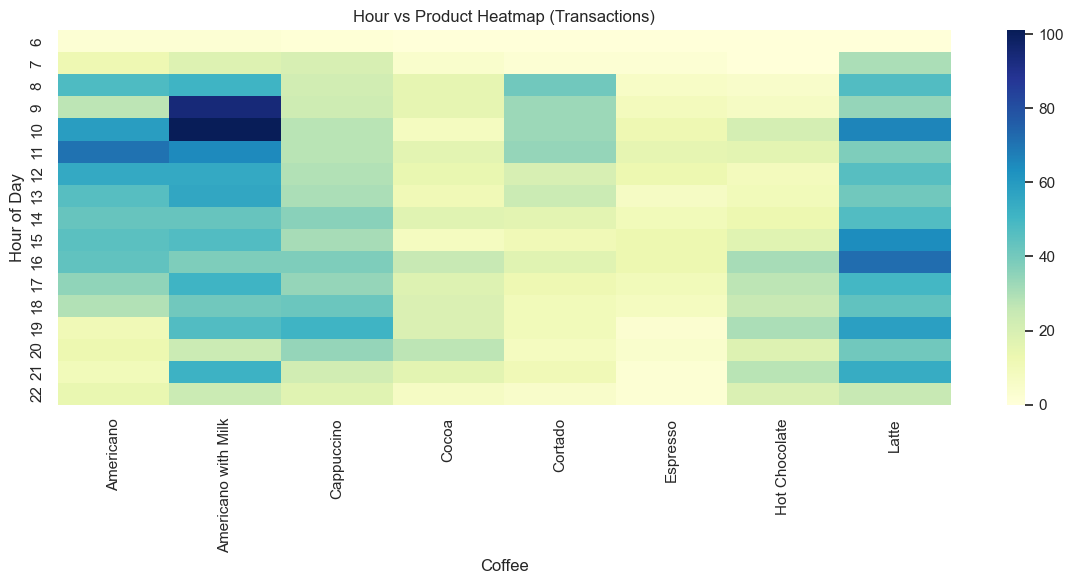

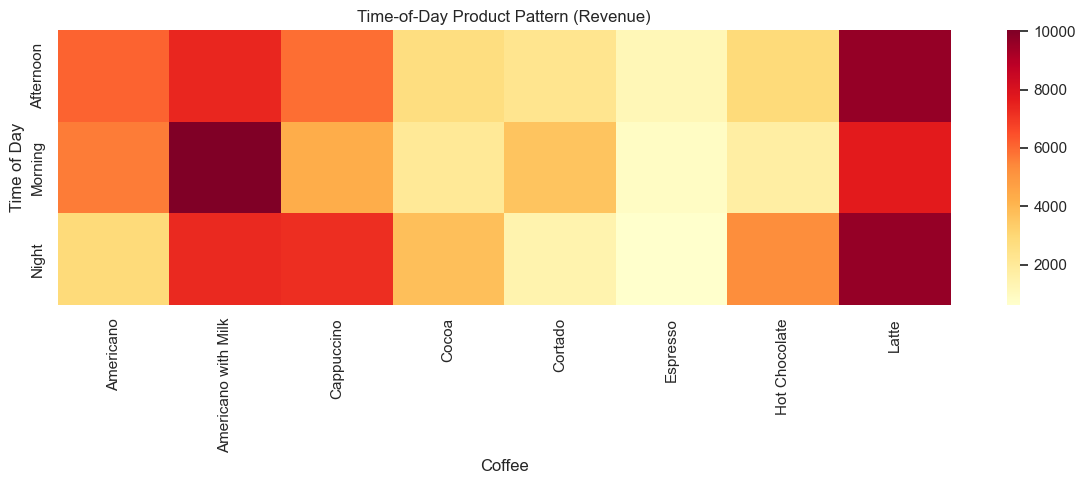

In [17]:
fig = plot_hour_product_heatmap(eda_df)
plt.tight_layout()
plt.show()

fig = plot_time_product_heatmap(eda_df)
plt.tight_layout()
plt.show()

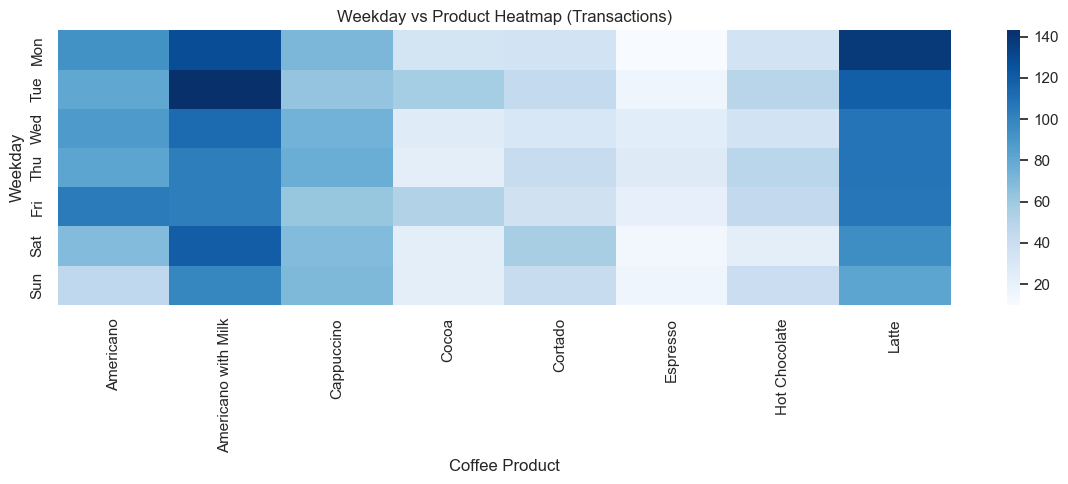

In [18]:
weekday_ordered_df = eda_df.copy()
weekday_ordered_df['Weekday'] = pd.Categorical(
    weekday_ordered_df['Weekday'], categories=WEEKDAY_ORDER, ordered=True
)

weekday_product = pd.crosstab(
    index=weekday_ordered_df['Weekday'],
    columns=weekday_ordered_df['coffee_name'],
    values=weekday_ordered_df['money'],
    aggfunc='size',
    dropna=False,
).fillna(0)

plt.figure(figsize=(12, 5))
sns.heatmap(weekday_product, cmap='Blues')
plt.title('Weekday vs Product Heatmap (Transactions)')
plt.xlabel('Coffee Product')
plt.ylabel('Weekday')
plt.tight_layout()
plt.show()

In [19]:
tod_product_crosstab = pd.crosstab(eda_df['Time_of_Day'], eda_df['coffee_name'])
tod_product_crosstab = tod_product_crosstab.reindex(['Morning', 'Afternoon', 'Night'])
display(tod_product_crosstab)

dominant_product_per_hour = (
    eda_df.groupby(['hour_of_day', 'coffee_name'], as_index=False)
    .agg(transactions=('money', 'size'))
    .sort_values(['hour_of_day', 'transactions'], ascending=[True, False])
    .groupby('hour_of_day', as_index=False)
    .head(1)
    .sort_values('hour_of_day')
    .reset_index(drop=True)
)
display(dominant_product_per_hour)

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
Time_of_Day,,,,,,,,
Morning,219,331,122,58,143,44,49,215
Afternoon,233,239,164,75,88,56,80,270
Night,112,239,200,106,56,29,147,272


,hour_of_day,coffee_name,transactions
0,6,Americano,2
1,7,Latte,30
2,8,Americano with Milk,51
3,9,Americano with Milk,94
4,10,Americano with Milk,101
5,11,Americano,71
6,12,Americano,55
7,13,Americano with Milk,56
8,14,Latte,47
9,15,Latte,64


## Summary

### Key Findings from EDA

**Checkpoint 1 — Data Understanding**
- Dataset contains 3,547 transactions across 381 unique trading days (2024-03-01 → 2025-03-23).
- All 11 required columns are present; 8 distinct products are sold.
- Transactions are bounded to the 06:00–22:00 window; no overnight activity exists.

**Checkpoint 2 — Data Quality**
- No critical null values in `money`, `coffee_name`, `Date`, or `Time`.
- All categorical columns (`Weekday`, `Month_name`, `Time_of_Day`, `coffee_name`, `cash_type`) fall within their expected allowed sets — no invalid category values detected.
- IQR outlier check on `money` is consistent with the fixed price-point structure (18.12–38.70 range); no anomalous pricing rows are expected.
- The dataset is card-only (`cash_type = card`); payment-method comparison is not applicable.

**Checkpoint 3 — Temporal Trends**
- Peak transaction hours fall within the morning-to-early-afternoon window (≈ 08:00–14:00).
- Weekday revenue varies across Mon–Sun; the weekday revenue chart identifies the highest and lowest performing days.
- Monthly revenue line chart reveals any seasonal patterns or growth across the 12-month observation window.
- `Morning` and `Afternoon` together account for the majority of both transaction volume and revenue.

**Checkpoint 4 — Product Performance**
- All 8 products are represented across the full observation period.
- Volume and revenue rankings may diverge — a high-volume product is not necessarily the top revenue generator.
- Average ticket value differs per product, reflecting fixed prices per item.
- The stacked bar chart shows how product popularity shifts across `Morning`, `Afternoon`, and `Night` segments.

**Checkpoint 5 — Behavioral Patterns**
- Hour × product heatmap exposes hourly purchase concentration for each product.
- Weekday × product heatmap shows whether certain products are more popular on particular days.
- The Time-of-Day × product cross-tabulation and dominant-product-per-hour table confirm which product leads each time segment.

---

This notebook serves as the validated, enriched data foundation for:
- `02_cleaning.ipynb` — detailed cleaning and transformation log
- `03_analysis.ipynb` — business insights with charts and recommendations
